In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches 

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update(
    {
        'text.usetex': True
    }
)

In [2]:
# NOTE: AISTATS paper dimensions 
page_width_pt = 487.8225 
column_width_pt = 234.8775

def set_figure_size(width_pt, fraction=0.9, subplots=(1, 1), ratio=(5**0.5 - 1) / 2):
    fig_width_pt = width_pt * fraction
    inches_per_pt = 1 / 72.27

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

base_figure_size = set_figure_size(page_width_pt, 0.9, (1, 1))

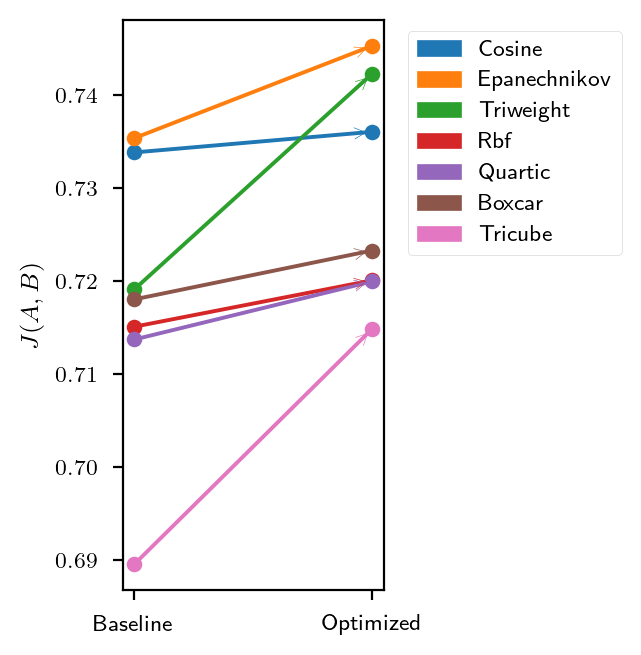

In [5]:
logs_folder = "/Users/shree/Documents/Programming/resource-efficient-ml/hyperparameter-optimization/outputs/logs"

# Initialize data storage
data = []

# Read all CSV files in the folder
for file in os.listdir(logs_folder):
    if file.endswith(".csv"):
        kernel_name = file.replace("optimization_log_", "").replace(".csv", "").capitalize()
        filepath = os.path.join(logs_folder, file)
        df = pd.read_csv(filepath)
        baseline_score = df["score"].iloc[0]  # First score as baseline
        optimized_score = df["score"].max()  # Max score as optimized
        data.append((kernel_name, baseline_score, optimized_score))

# Convert to DataFrame for easier handling
results = pd.DataFrame(data, columns=["Kernel", "Baseline", "Optimized"])

# Plotting
plt.figure(figsize=set_figure_size(page_width_pt, fraction=0.5, ratio=1.))
colors = plt.cm.tab10(range(len(results)))  # Color map for kernels
for i, row in results.iterrows():
    plt.plot([1, 2], [row["Baseline"], row["Optimized"]], marker="o", color=colors[i], label=row["Kernel"])
    plt.annotate("", xy=(2, row["Optimized"]), xytext=(1, row["Baseline"]),
                 arrowprops=dict(arrowstyle="->", color=colors[i]))

# Customize plot
plt.xticks([1, 2], ["Baseline", "Optimized"])
plt.ylabel(r"$J(A, B)$")
# plt.title("Baseline vs Optimized Scores for Each Kernel")
plt.legend(handles=[patches.Patch(color=colors[i], label=row["Kernel"]) for i, row in results.iterrows()],bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
# plt.grid()
plt.savefig('/Users/shree/Documents/Programming/resource-efficient-ml/hyperparameter-optimization/outputs/figures/hyperparamter_optimisation.pgf')
plt.show()